# B — Traditional Model: SIFT + BoVW + SVM

This notebook walks through our traditional baseline and shows the key results.
The actual implementation lives in `src/train_traditional.py` and
`src/predict_traditional.py` — this notebook imports from those files rather
than repeating the code, and focuses on the numbers and charts.

In [3]:
import os

try:
    notebook_dir = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    notebook_dir = os.getcwd()

PROJECT_ROOT = os.path.dirname(notebook_dir)
os.chdir(PROJECT_ROOT)

import sys
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

print("notebook file located at:", notebook_dir)
print("project root set to:", PROJECT_ROOT)
print("data/splits exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "data", "splits")))
print("data/raw exists:", os.path.isdir(os.path.join(PROJECT_ROOT, "data", "raw")))

import json
import numpy as np
import pandas as pd
import cv2
import joblib
from PIL import Image
import matplotlib.pyplot as plt
from degradations import apply_degradation

print("imports ok")

notebook file located at: e:\26T2\9517\group project\COMP9517-project\notebooks
project root set to: e:\26T2\9517\group project\COMP9517-project
data/splits exists: True
data/raw exists: True
imports ok


## 1. SIFT + BoVW + SVM overview

Pipeline: extract SIFT keypoints/descriptors from each image → build a 512-word
visual vocabulary with k-means → encode each image as a BoVW histogram → classify
with an SVM (rbf kernel, C=10).

Full training took ~44 min, full prediction (clean + 15 robustness variants) took
~68 min — both were run once via the scripts below, and this notebook just loads
the results.

## 2. Dataset split loading

In [4]:
train_df = pd.read_csv("data/splits/train_paths.csv")
val_df = pd.read_csv("data/splits/val_paths.csv")
test_df = pd.read_csv("data/splits/test_paths.csv")

print(f"train: {len(train_df)} images, val: {len(val_df)}, test: {len(test_df)}")
print(f"classes: {train_df['class_idx'].nunique()}")
train_df.head()

train: 20000 images, val: 5000, test: 5000
classes: 500


,image_path,image_id,category_id,label,class_idx,split
0,data\raw\train_mini\00044_Animalia_Arthropoda_...,1193734,44,Trichonephila clavata,0,train
1,data\raw\train_mini\00044_Animalia_Arthropoda_...,2088407,44,Trichonephila clavata,0,train
2,data\raw\train_mini\00044_Animalia_Arthropoda_...,2057844,44,Trichonephila clavata,0,train
3,data\raw\train_mini\00044_Animalia_Arthropoda_...,1193967,44,Trichonephila clavata,0,train
4,data\raw\train_mini\00044_Animalia_Arthropoda_...,1233980,44,Trichonephila clavata,0,train


## 3. SIFT keypoint example

What the feature extraction step actually looks like on a real image.

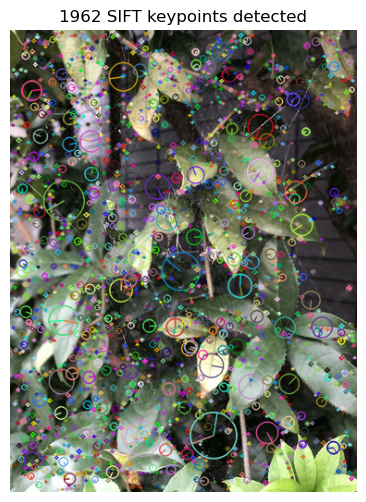

In [5]:
sift = cv2.SIFT_create()

sample_path = test_df.iloc[0]["image_path"]
img = cv2.imread(sample_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
keypoints, descriptors = sift.detectAndCompute(gray, None)

img_with_kp = cv2.drawKeypoints(
    img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_kp, cv2.COLOR_BGR2RGB))
plt.title(f"{len(keypoints)} SIFT keypoints detected")
plt.axis("off")
plt.show()

## 4. BoVW / SVM training settings

Vocabulary size and SVM hyperparameters were chosen by grid search on the
validation set (see `reports/SIFT_BoVW_SVM_dev_log.md` for the full experiment
log). Summary of that search:

In [6]:
vocab_search = pd.DataFrame([
    {"vocab_size": 128, "val_accuracy": 0.0714},
    {"vocab_size": 256, "val_accuracy": 0.0826},
    {"vocab_size": 512, "val_accuracy": 0.0890},
])
print("Vocabulary size search (SVM rbf, C=1.0):")
display(vocab_search)

svm_search = pd.DataFrame([
    {"kernel": "rbf", "C": 10, "val_accuracy": 0.1066},
    {"kernel": "rbf", "C": 100, "val_accuracy": 0.1066},
    {"kernel": "linear", "C": 10, "val_accuracy": 0.0938},
    {"kernel": "rbf", "C": 1, "val_accuracy": 0.0890},
    {"kernel": "linear", "C": 1, "val_accuracy": 0.0756},
    {"kernel": "rbf", "C": 0.1, "val_accuracy": 0.0542},
])
print("\nSVM hyperparameter search (vocab_size=512):")
display(svm_search.sort_values("val_accuracy", ascending=False))

print("\n=> final config: vocab_size=512, kernel=rbf, C=10")

Vocabulary size search (SVM rbf, C=1.0):


,vocab_size,val_accuracy
0,128,0.0714
1,256,0.0826
2,512,0.0890



SVM hyperparameter search (vocab_size=512):


,kernel,C,val_accuracy
0,rbf,10.0,0.1066
1,rbf,100.0,0.1066
2,linear,10.0,0.0938
3,rbf,1.0,0.0890
4,linear,1.0,0.0756
5,rbf,0.1,0.0542



=> final config: vocab_size=512, kernel=rbf, C=10


## 5. Quick live prediction with our trained model

Loading the actual trained vocabulary + SVM from `train_traditional.py`'s run,
and running a few real predictions using the same `encode_bovw` /
`extract_descriptors` functions from `predict_traditional.py`.

In [7]:
from predict_traditional import extract_descriptors, encode_bovw, load_models

kmeans, svm = load_models()

idx_to_name = dict(zip(train_df["class_idx"], train_df["label"]))

sample = test_df.sample(5, random_state=9517)

rows = []
for _, row in sample.iterrows():
    img = Image.open(row.image_path).convert("RGB")
    desc = extract_descriptors(img, sift)
    feat = encode_bovw(desc, kmeans, 512).reshape(1, -1)

    scores = svm.decision_function(feat)
    pred_idx = svm.classes_[np.argmax(scores)]

    rows.append({
        "true_species": idx_to_name[row.class_idx],
        "predicted_species": idx_to_name[pred_idx],
        "correct": pred_idx == row.class_idx,
    })

prediction_demo_df = pd.DataFrame(rows)
display(prediction_demo_df)


Loading vocabulary from results/models\traditional_kmeans_k512.pkl


d:\anaconda3\envs\comp9517\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MiniBatchKMeans from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading SVM from results/models\traditional_svm.pkl


d:\anaconda3\envs\comp9517\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,true_species,predicted_species,correct
0,Scarus ghobban,Scarus ghobban,True
1,Leucadendron salignum,Leucadendron salignum,True
2,Carduus pycnocephalus,Myzinum quinquecinctum,False
3,Helicoverpa armigera,Sparassis spathulata,False
4,Numenius americanus,Platalea leucorodia,False


## 6. Clean test metrics

Full test set (5,000 images), from the official `predict_traditional.py` run.

,metric,value
0,top1_accuracy,0.107400
1,top5_accuracy,0.230400
2,macro_precision,0.104693
3,macro_recall,0.107400
4,macro_f1,0.098175


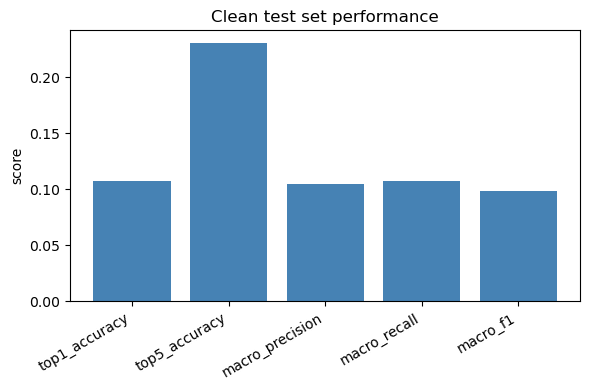

In [8]:
with open("results/clean/traditional_metrics.json") as f:
    clean_metrics = json.load(f)

metrics_to_show = ["top1_accuracy", "top5_accuracy", "macro_precision", "macro_recall", "macro_f1"]
metrics_df = pd.DataFrame([
    {"metric": m, "value": clean_metrics[m]} for m in metrics_to_show
])
display(metrics_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(metrics_df["metric"], metrics_df["value"], color="steelblue")
ax.set_ylabel("score")
ax.set_title("Clean test set performance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Robustness result

5 degradation types x 3 severities, all on the full 5,000-image test set.

,model,degradation,severity,top1_accuracy,top5_accuracy,macro_precision,macro_recall,macro_f1,metrics_json
0,traditional,clean,0.00,0.1074,0.2304,0.104693,0.1074,0.098175,D:/Code/unsw/comp9517/COMP9517-project-github/...
1,traditional,noise,0.05,0.0946,0.2218,0.098196,0.0946,0.086117,D:/Code/unsw/comp9517/COMP9517-project-github/...
2,traditional,noise,0.10,0.0796,0.1884,0.080901,0.0796,0.068765,D:/Code/unsw/comp9517/COMP9517-project-github/...
3,traditional,noise,0.20,0.0392,0.1042,0.053533,0.0392,0.031154,D:/Code/unsw/comp9517/COMP9517-project-github/...
4,traditional,blur,3.00,0.0542,0.1494,0.072101,0.0542,0.049134,D:/Code/unsw/comp9517/COMP9517-project-github/...
5,traditional,blur,5.00,0.0212,0.0692,0.028758,0.0212,0.016658,D:/Code/unsw/comp9517/COMP9517-project-github/...
6,traditional,blur,7.00,0.0090,0.0326,0.004680,0.0090,0.004252,D:/Code/unsw/comp9517/COMP9517-project-github/...
7,traditional,brightness,0.40,0.0412,0.1148,0.074383,0.0412,0.040472,D:/Code/unsw/comp9517/COMP9517-project-github/...
8,traditional,brightness,0.60,0.0870,0.2006,0.103242,0.0870,0.082221,D:/Code/unsw/comp9517/COMP9517-project-github/...
9,traditional,brightness,0.80,0.1006,0.2272,0.100552,0.1006,0.092049,D:/Code/unsw/comp9517/COMP9517-project-github/...


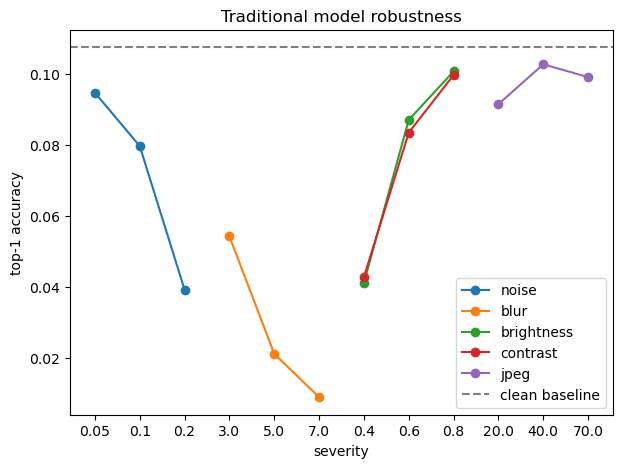

In [9]:
robust_df = pd.read_csv("results/robustness/combined_robustness_results.csv")
robust_df = robust_df[robust_df["model"] == "traditional"]
display(robust_df)

fig, ax = plt.subplots(figsize=(7, 5))
for deg in ["noise", "blur", "brightness", "contrast", "jpeg"]:
    sub = robust_df[robust_df["degradation"] == deg].sort_values("severity")
    ax.plot(sub["severity"].astype(str), sub["top1_accuracy"], marker="o", label=deg)

clean_acc = robust_df[robust_df["degradation"] == "clean"]["top1_accuracy"].values[0]
ax.axhline(clean_acc, color="gray", linestyle="--", label="clean baseline")

ax.set_xlabel("severity")
ax.set_ylabel("top-1 accuracy")
ax.set_title("Traditional model robustness")
ax.legend()
plt.show()

## 7.5 Deeper analysis: per-class performance, confusion patterns, and a color-only baseline

Beyond aggregate accuracy, this section looks at *which* classes the model succeeds/fails on,
*why* (via a color-histogram-only baseline for comparison), and whether blur/noise measurably
reduce the number of SIFT keypoints detected.

### Per-class best / worst performance

In [10]:
per_class_acc = np.array(clean_metrics["per_class_accuracy"])
sorted_idx = np.argsort(per_class_acc)

worst_rows = [
    {"group": "worst", "species": idx_to_name[idx], "accuracy": per_class_acc[idx]}
    for idx in sorted_idx[:5]
]
best_rows = [
    {"group": "best", "species": idx_to_name[idx], "accuracy": per_class_acc[idx]}
    for idx in sorted_idx[-5:][::-1]
]

per_class_df = pd.DataFrame(worst_rows + best_rows)
display(per_class_df)


,group,species,accuracy
0,worst,Linanthus dianthiflorus,0.0
1,worst,Callipepla californica,0.0
2,worst,Anthropoides virgo,0.0
3,worst,Spiza americana,0.0
4,worst,Corvus frugilegus,0.0
5,best,Dibaeis baeomyces,0.7
6,best,Pteris macilenta,0.6
7,best,Scleroderma citrinum,0.6
8,best,Tabebuia rosea,0.6
9,best,Pollicipes polymerus,0.5


### Most confused class pairs

In [11]:
def get_genus(name):
    return name.split()[0]

cm = np.array(clean_metrics["confusion_matrix"])
np.fill_diagonal(cm, 0)
flat_idx = np.argsort(cm.ravel())[::-1][:10]

rows = []
for idx in flat_idx:
    true_i, pred_i = np.unravel_index(idx, cm.shape)
    true_name, pred_name = idx_to_name[true_i], idx_to_name[pred_i]
    rows.append({
        "true_species": true_name,
        "predicted_species": pred_name,
        "count": int(cm[true_i, pred_i]),
        "same_genus": get_genus(true_name) == get_genus(pred_name),
    })

confused_pairs_df = pd.DataFrame(rows)
display(confused_pairs_df)


,true_species,predicted_species,count,same_genus
0,Lysimachia quadriflora,Carex hystericina,4,False
1,Buteo swainsoni,Haliaeetus albicilla,3,False
2,Acrostichum danaeifolium,Protea repens,3,False
3,Erigeron canadensis,Cladophora columbiana,3,False
4,Isocoma acradenia,Gutierrezia sarothrae,3,False
5,Rubus laciniatus,Leonurus cardiaca,3,False
6,Cominella adspersa,Cyrtopleura costata,3,False
7,Helianthus maximiliani,Leucoagaricus leucothites,3,False
8,Anas gracilis,Haliaeetus albicilla,3,False
9,Opisthograptis luteolata,Microtheoris vibicalis,3,False


Interestingly, **none of the top-10 most-confused pairs are from the same genus** — the model's
mistakes aren't driven by visually similar close relatives. This is consistent with a known
limitation of BoVW: it discards spatial layout entirely, so confusion is more likely driven by
shared background/texture statistics (e.g. water, foliage) than by true species similarity.

### Keypoint count vs. blur severity

In [12]:
sample_path = test_df.iloc[0]["image_path"]

rows = []
for severity in [None, 3, 5, 7]:
    img = Image.open(sample_path).convert("RGB")
    if severity is not None:
        img = apply_degradation(img, "blur", severity)
    gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
    kp, _ = sift.detectAndCompute(gray, None)
    label = "clean" if severity is None else f"blur={severity}"
    rows.append({"condition": label, "keypoints_detected": len(kp)})

keypoint_df = pd.DataFrame(rows)
display(keypoint_df)


,condition,keypoints_detected
0,clean,1962
1,blur=3,1168
2,blur=5,496
3,blur=7,250


### Color Histogram + SVM: a simple additional baseline

,model,top1,top5,macro_f1
0,SIFT + BoVW + SVM,0.1074,0.2304,0.098175
1,Color Histogram + SVM,0.0410,0.1190,0.038432


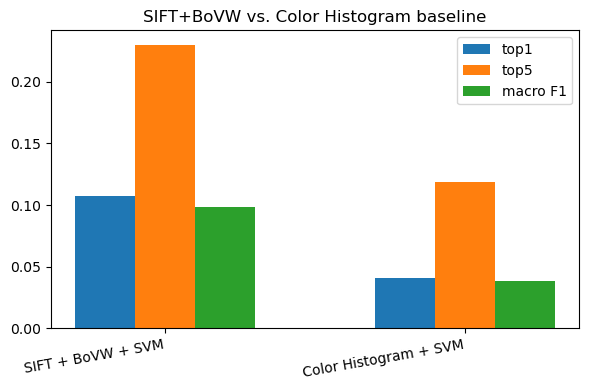

,type,species,sift_acc,color_acc
0,color more informative,Amanita jacksonii,0.1,0.4
1,color more informative,Linanthus dianthiflorus,0.0,0.3
2,color more informative,Oenothera gaura,0.0,0.3
3,color more informative,Sedum lanceolatum,0.0,0.3
4,color more informative,Senecio ampullaceus,0.0,0.2
5,shape/texture more informative,Pteris macilenta,0.6,0.0
6,shape/texture more informative,Scleroderma citrinum,0.6,0.0
7,shape/texture more informative,Hydrocotyle ranunculoides,0.5,0.0
8,shape/texture more informative,Pollicipes polymerus,0.5,0.0
9,shape/texture more informative,Texola elada,0.5,0.0


In [13]:
with open("results/extra/color_histogram_metrics.json") as f:
    color_metrics = json.load(f)

comparison = pd.DataFrame([
    {"model": "SIFT + BoVW + SVM", "top1": clean_metrics["top1_accuracy"],
     "top5": clean_metrics["top5_accuracy"], "macro_f1": clean_metrics["macro_f1"]},
    {"model": "Color Histogram + SVM", "top1": color_metrics["top1_accuracy"],
     "top5": color_metrics["top5_accuracy"], "macro_f1": color_metrics["macro_f1"]},
])
display(comparison)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(comparison))
ax.bar(x - 0.2, comparison["top1"], width=0.2, label="top1")
ax.bar(x, comparison["top5"], width=0.2, label="top5")
ax.bar(x + 0.2, comparison["macro_f1"], width=0.2, label="macro F1")
ax.set_xticks(x)
ax.set_xticklabels(comparison["model"], rotation=10, ha="right")
ax.legend()
ax.set_title("SIFT+BoVW vs. Color Histogram baseline")
plt.tight_layout()
plt.show()

color_acc = np.array(color_metrics["per_class_accuracy"])
diff = color_acc - per_class_acc

color_rows = [
    {"type": "color more informative", "species": idx_to_name[idx],
     "sift_acc": per_class_acc[idx], "color_acc": color_acc[idx]}
    for idx in np.argsort(diff)[-5:][::-1]
]
shape_rows = [
    {"type": "shape/texture more informative", "species": idx_to_name[idx],
     "sift_acc": per_class_acc[idx], "color_acc": color_acc[idx]}
    for idx in np.argsort(diff)[:5]
]

color_vs_shape_df = pd.DataFrame(color_rows + shape_rows)
display(color_vs_shape_df)


## 8. Short discussion

- Clean top-1 accuracy: ~10.7% on this 500-class fine-grained task — far above the
  0.2% random baseline, but this is a known limitation of hand-crafted features on
  fine-grained classification (this is exactly the comparison point against the
  deep learning models).
- **Blur is the most damaging degradation** (accuracy collapses to ~1% at the
  strongest level). SIFT relies on local edges/gradients to find keypoints, and
  blur destroys that structure directly — confirmed directly by the keypoint
  count dropping as blur severity increases.
- **JPEG compression barely matters** — SIFT keypoints tend to sit on strong,
  compression-resistant edges.
- A simple color-histogram baseline scores far lower (top1 ~4.1% vs. 10.7%),
  confirming shape/texture information (captured by SIFT) matters more than
  color for this task overall — though a handful of visually distinct species
  (e.g. brightly colored fungi/flowers) are actually easier for the color-only
  model, and the most-confused class pairs are never from the same genus,
  suggesting BoVW's mistakes are driven more by shared background/texture
  statistics than by true species similarity.
- Full engineering log (memory issues, hyperparameter search, timing) is in
  `reports/SIFT_BoVW_SVM_dev_log.md`.